In [34]:
import pandas as pd
import numpy as np
from scipy import stats
import statsmodels.api as sm
from statsmodels.formula.api import ols
import matplotlib.pyplot as plt
import seaborn as sns
import itertools

pd.set_option('display.float_format', lambda x: f'{x:,.3f}')
sns.set_style('whitegrid')
PALETTE = {'Kharif': '#2E7D32', 'Rabi': '#1565C0', 'Zaid': '#E65100'}

df = pd.read_csv('/content/drive/MyDrive/VOIS Internship/seasonal_agriculture_performance_dataset.csv')
seasons = ['Kharif', 'Rabi', 'Zaid']
print(f'Shape: {df.shape[0]} rows x {df.shape[1]} columns')
df.head(3)

Shape: 4000 rows x 28 columns


,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.530,486.400,24.300,69.100,5.800,...,0.760,2.460,1.300,23700,42662,30810,-11852,237,5.485,55.300
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.530,855.400,25.700,78.400,5.100,...,0.940,0.300,1.960,20613,492351,40401,-451950,4953,0.396,49.900
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.860,455.600,23.900,56.400,10.300,...,0.980,0.520,2.530,75283,315210,190466,-124744,1275,1.984,33.700


In [35]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [36]:
missing = df.isna().sum()
missing = missing[missing > 0]
print('Missing values by column:')
print(missing)
print(f'\nTotal missing cells: {missing.sum()} of {df.size} ({missing.sum()/df.size*100:.2f}%)')

print(f"\nFarm_ID unique: {df['Farm_ID'].is_unique}")

print('\nSeason counts:')
print(df['Season'].value_counts())

Missing values by column:
Rainfall_mm          48
Soil_Moisture_pct    40
Yield_Tonnes_Ha      32
dtype: int64

Total missing cells: 120 of 112000 (0.11%)

Farm_ID unique: True

Season counts:
Season
Kharif    1779
Rabi      1627
Zaid       594
Name: count, dtype: int64


In [37]:
df_yield = df.dropna(subset=['Yield_Tonnes_Ha']).copy()

df['Cost_Per_Hectare']       = df['Total_Cost_INR'] / df['Farm_Area_Hectares']
df['Profit_Per_Hectare']     = df['Profit_INR'] / df['Farm_Area_Hectares']
df['Profit_Margin_Pct']      = (df['Profit_INR'] / df['Revenue_INR']) * 100
df['Revenue_Per_Unit_Cost']  = df['Revenue_INR'] / df['Total_Cost_INR']

print('Derived metrics added: Cost_Per_Hectare, Profit_Per_Hectare, Profit_Margin_Pct, Revenue_Per_Unit_Cost')
df[['Farm_ID','Season','Profit_INR','Farm_Area_Hectares','Profit_Per_Hectare','Profit_Margin_Pct']].head(3)

Derived metrics added: Cost_Per_Hectare, Profit_Per_Hectare, Profit_Margin_Pct, Revenue_Per_Unit_Cost


,Farm_ID,Season,Profit_INR,Farm_Area_Hectares,Profit_Per_Hectare,Profit_Margin_Pct
0,SF10001,Kharif,-11852,0.530,"-22,362.264",-38.468
1,SF10002,Kharif,-451950,6.530,"-69,211.332","-1,118.660"
2,SF10003,Rabi,-124744,4.860,"-25,667.490",-65.494


/tmp/ipykernel_2621/2653549810.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Season', y='Yield_Tonnes_Ha', order=seasons, palette=PALETTE, ax=axes[0,1])
/tmp/ipykernel_2621/2653549810.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Season', y='Profit_Per_Hectare', order=seasons, palette=PALETTE, ax=axes[1,0])
/tmp/ipykernel_2621/2653549810.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Season', y='Rainfall_mm', order=seasons, palette=PALETTE, ax=axes[1,1])


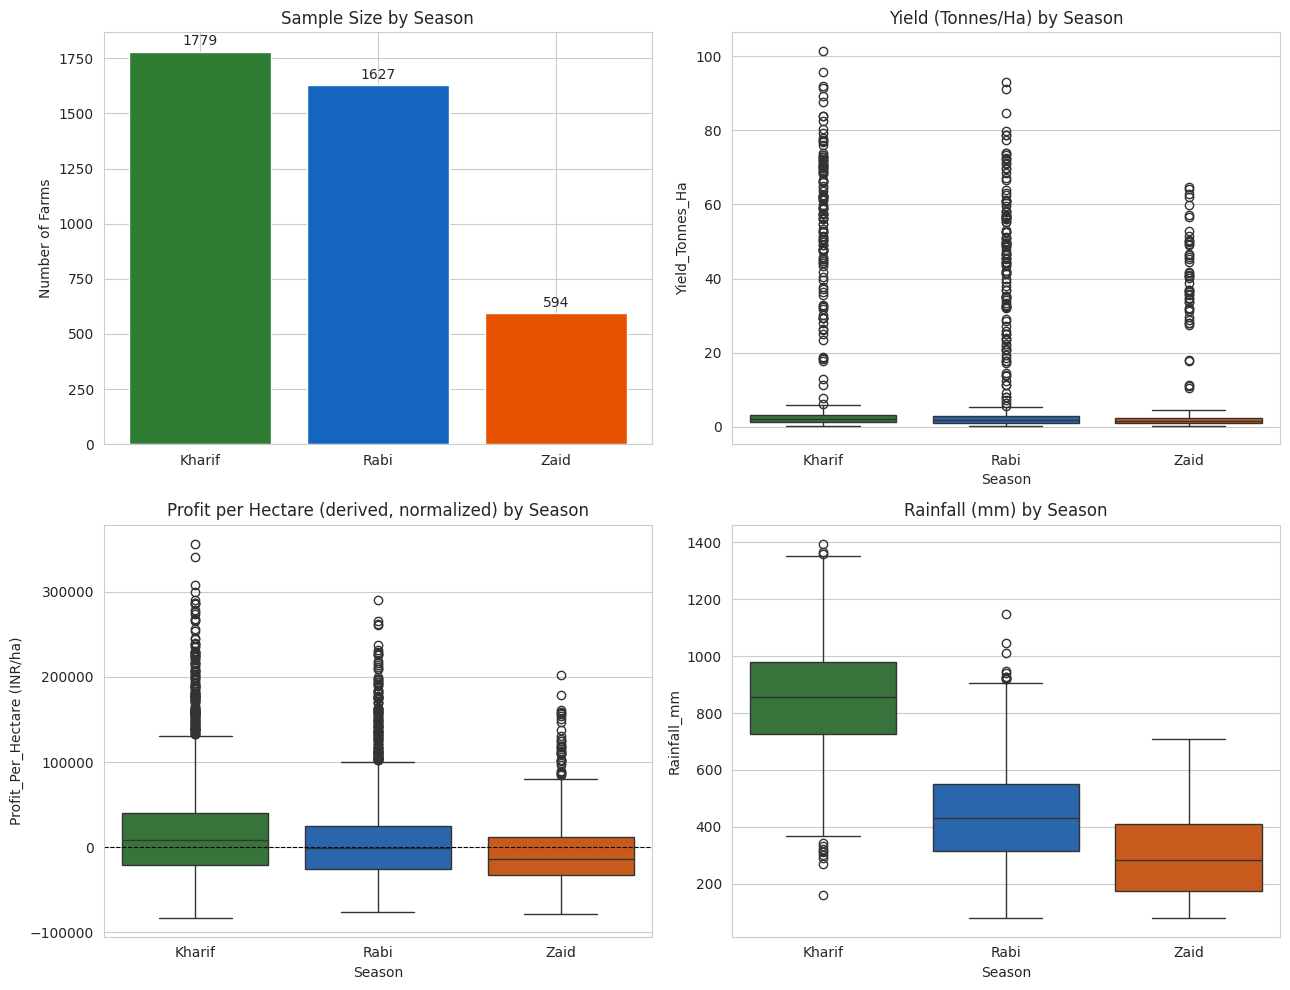

In [38]:
fig, axes = plt.subplots(2, 2, figsize=(13, 10))

season_counts = df['Season'].value_counts().reindex(seasons)
axes[0,0].bar(season_counts.index, season_counts.values, color=[PALETTE[s] for s in seasons])
axes[0,0].set_title('Sample Size by Season')
axes[0,0].set_ylabel('Number of Farms')
for i, v in enumerate(season_counts.values):
    axes[0,0].text(i, v + 30, str(v), ha='center')

sns.boxplot(data=df, x='Season', y='Yield_Tonnes_Ha', order=seasons, palette=PALETTE, ax=axes[0,1])
axes[0,1].set_title('Yield (Tonnes/Ha) by Season')

sns.boxplot(data=df, x='Season', y='Profit_Per_Hectare', order=seasons, palette=PALETTE, ax=axes[1,0])
axes[1,0].axhline(0, color='black', linewidth=0.8, linestyle='--')
axes[1,0].set_title('Profit per Hectare (derived, normalized) by Season')
axes[1,0].set_ylabel('Profit_Per_Hectare (INR/ha)')

sns.boxplot(data=df, x='Season', y='Rainfall_mm', order=seasons, palette=PALETTE, ax=axes[1,1])
axes[1,1].set_title('Rainfall (mm) by Season')

plt.tight_layout()
plt.show()

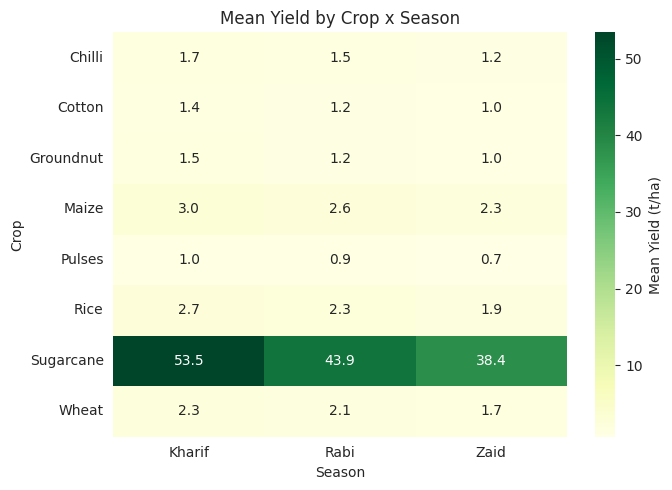

In [39]:
pivot = df_yield.pivot_table(index='Crop', columns='Season', values='Yield_Tonnes_Ha', aggfunc='mean')[seasons]
plt.figure(figsize=(7, 5))
sns.heatmap(pivot, annot=True, fmt='.1f', cmap='YlGn', cbar_kws={'label': 'Mean Yield (t/ha)'})
plt.title('Mean Yield by Crop x Season')
plt.tight_layout()
plt.show()

In [40]:
yield_groups = [df.loc[df.Season == s, 'Yield_Tonnes_Ha'].dropna() for s in seasons]

print('Normality (Shapiro-Wilk on a random sample of <=500) and skewness:')
for s, g in zip(seasons, yield_groups):
    sh = stats.shapiro(g.sample(min(len(g), 500), random_state=1))
    print(f'  {s}: n={len(g)}, skew={stats.skew(g):.2f}, Shapiro p={sh.pvalue:.3g}')

lev = stats.levene(*yield_groups)
print(f'\nLevene (equal variances): stat={lev.statistic:.3f}, p={lev.pvalue:.3g}')
print('\n=> Yield is strongly right-skewed and fails normality in every season (all p << .001).')
print('=> Non-parametric tests (Kruskal-Wallis, Mann-Whitney, Spearman) are used throughout instead of ANOVA/Pearson.')

Normality (Shapiro-Wilk on a random sample of <=500) and skewness:
  Kharif: n=1772, skew=4.03, Shapiro p=2.94e-38
  Rabi: n=1607, skew=4.04, Shapiro p=6.5e-39
  Zaid: n=589, skew=3.54, Shapiro p=9.25e-38

Levene (equal variances): stat=0.759, p=0.468

=> Yield is strongly right-skewed and fails normality in every season (all p << .001).
=> Non-parametric tests (Kruskal-Wallis, Mann-Whitney, Spearman) are used throughout instead of ANOVA/Pearson.


In [41]:
def epsilon_squared(H, N, k):
    return (H - k + 1) / (N - k)

def posthoc_mannwhitney(data, col, group_col, groups):
    g = {s: data.loc[data[group_col] == s, col].dropna() for s in groups}
    pairs = list(itertools.combinations(groups, 2))
    m = len(pairs)
    rows = []
    for a, b in pairs:
        u = stats.mannwhitneyu(g[a], g[b], alternative='two-sided')
        n1, n2 = len(g[a]), len(g[b])
        rbc = 1 - (2 * u.statistic) / (n1 * n2)
        rows.append({'Group A': a, 'Group B': b, 'p_raw': u.pvalue,
                     'p_bonferroni': min(u.pvalue * m, 1.0), 'rank_biserial_r': rbc, 'n_A': n1, 'n_B': n2})
    return pd.DataFrame(rows)

kw = stats.kruskal(*yield_groups)
N, k = sum(len(g) for g in yield_groups), len(yield_groups)
eps = epsilon_squared(kw.statistic, N, k)
print(f'Kruskal-Wallis: H={kw.statistic:.3f}, df={k-1}, p={kw.pvalue:.3g}, epsilon^2={eps:.4f} (small effect)')
for s, g in zip(seasons, yield_groups):
    print(f'  {s}: median={g.median():.2f} t/ha, IQR={g.quantile(.75)-g.quantile(.25):.2f}, n={len(g)}')

print('\nPost-hoc pairwise comparisons (Mann-Whitney U, Bonferroni-corrected):')
posthoc_mannwhitney(df, 'Yield_Tonnes_Ha', 'Season', seasons)

Kruskal-Wallis: H=68.604, df=2, p=1.27e-15, epsilon^2=0.0168 (small effect)
  Kharif: median=1.95 t/ha, IQR=1.92, n=1772
  Rabi: median=1.66 t/ha, IQR=1.73, n=1607
  Zaid: median=1.45 t/ha, IQR=1.44, n=589

Post-hoc pairwise comparisons (Mann-Whitney U, Bonferroni-corrected):


,Group A,Group B,p_raw,p_bonferroni,rank_biserial_r,n_A,n_B
0,Kharif,Rabi,0.000,0.000,-0.102,1772,1607
1,Kharif,Zaid,0.000,0.000,-0.215,1772,589
2,Rabi,Zaid,0.000,0.000,-0.117,1607,589


In [42]:
cost_groups = [df.loc[df.Season == s, 'Cost_Per_Hectare'].dropna() for s in seasons]
for s, g in zip(seasons, cost_groups):
    print(f'{s}: n={len(g)}, mean={g.mean():,.0f}, median={g.median():,.0f}')

kw_cost = stats.kruskal(*cost_groups)
N, k = sum(len(g) for g in cost_groups), len(cost_groups)
eps_cost = epsilon_squared(kw_cost.statistic, N, k)
print(f'\nKruskal-Wallis: H={kw_cost.statistic:.3f}, p={kw_cost.pvalue:.3g}, epsilon^2={eps_cost:.5f}')

Kharif: n=1779, mean=66,901, median=66,741
Rabi: n=1627, mean=66,295, median=66,281
Zaid: n=594, mean=66,938, median=66,743

Kruskal-Wallis: H=5.022, p=0.0812, epsilon^2=0.00076


In [43]:
d = df_yield.copy()
d['rank_yield'] = d['Yield_Tonnes_Ha'].rank()

model = ols('rank_yield ~ C(Season)*C(Crop)', data=d).fit()
aov = sm.stats.anova_lm(model, typ=2)

ms_total_var = np.var(d['rank_yield'], ddof=1)
ss_total = aov['sum_sq'].sum()

srh = aov.copy()
srh['H'] = srh['sum_sq'] / ms_total_var
srh['p_value'] = 1 - stats.chi2.cdf(srh['H'], srh['df'])
srh['eta_sq'] = srh['sum_sq'] / ss_total
srh[['df', 'H', 'p_value', 'eta_sq']]

,df,H,p_value,eta_sq
C(Season),2.000,79.927,0.000,0.020
C(Crop),7.000,"1,864.525",0.000,0.469
C(Season):C(Crop),14.000,8.360,0.870,0.002
Residual,"3,944.000","2,025.510",1.000,0.509


In [44]:
irr_methods = df['Irrigation_Method'].dropna().unique().tolist()
irr_groups = [df.loc[df.Irrigation_Method == m, 'Yield_Tonnes_Ha'].dropna() for m in irr_methods]

kw_irr = stats.kruskal(*irr_groups)
N, k = sum(len(g) for g in irr_groups), len(irr_groups)
eps_irr = epsilon_squared(kw_irr.statistic, N, k)
print(f'Kruskal-Wallis: H={kw_irr.statistic:.3f}, p={kw_irr.pvalue:.3g}, epsilon^2={eps_irr:.4f}')

print('\nPost-hoc (Mann-Whitney, Bonferroni):')
posthoc_mannwhitney(df, 'Yield_Tonnes_Ha', 'Irrigation_Method', irr_methods)

Kruskal-Wallis: H=22.439, p=5.29e-05, epsilon^2=0.0049

Post-hoc (Mann-Whitney, Bonferroni):


,Group A,Group B,p_raw,p_bonferroni,rank_biserial_r,n_A,n_B
0,Drip,Flood,0.000,0.000,-0.108,907,1296
1,Drip,Rainfed,0.000,0.000,-0.106,907,1037
2,Drip,Sprinkler,0.022,0.131,-0.066,907,728
3,Flood,Rainfed,0.818,1.000,0.006,1296,1037
4,Flood,Sprinkler,0.128,0.769,0.041,1296,728
5,Rainfed,Sprinkler,0.178,1.000,0.038,1037,728


In [45]:
num_cols = ['Rainfall_mm','Avg_Temperature_C','Humidity_pct','Sunlight_Hours_Day','Soil_pH',
            'Soil_Moisture_pct','Nitrogen_kg_ha','Phosphorus_kg_ha','Potassium_kg_ha','Fertilizer_kg_ha',
            'Pesticide_Litre_ha','Water_Used_m3','Seed_Quality_Score','Disease_Pest_Risk_pct']

rows = []
for c in num_cols:
    sub = df[[c, 'Yield_Tonnes_Ha']].dropna()
    rs, ps = stats.spearmanr(sub[c], sub['Yield_Tonnes_Ha'])
    rows.append({'Variable': c, 'Spearman_r': rs, 'p_value': ps})

corr_table = pd.DataFrame(rows).sort_values('Spearman_r', key=abs, ascending=False).reset_index(drop=True)
corr_table

,Variable,Spearman_r,p_value
0,Water_Used_m3,0.265,0.000
1,Rainfall_mm,0.131,0.000
2,Soil_Moisture_pct,0.098,0.000
3,Nitrogen_kg_ha,0.082,0.000
4,Humidity_pct,0.081,0.000
5,Disease_Pest_Risk_pct,0.065,0.000
6,Sunlight_Hours_Day,-0.051,0.001
7,Phosphorus_kg_ha,0.048,0.003
8,Soil_pH,-0.031,0.050
9,Potassium_kg_ha,0.025,0.113


In [46]:
states = df['State'].dropna().unique().tolist()
state_groups = [df.loc[df.State == s, 'Yield_Tonnes_Ha'].dropna() for s in states]
kw_state = stats.kruskal(*state_groups)
N, k = sum(len(g) for g in state_groups), len(state_groups)
eps_state = epsilon_squared(kw_state.statistic, N, k)
print(f'States tested: {len(states)}')
print(f'Kruskal-Wallis: H={kw_state.statistic:.3f}, p={kw_state.pvalue:.3g}, epsilon^2={eps_state:.5f}')

States tested: 8
Kruskal-Wallis: H=8.605, p=0.282, epsilon^2=0.00041


In [47]:
profit_features = ['Profit_Per_Hectare', 'Profit_Margin_Pct', 'Revenue_Per_Unit_Cost']
results = []
for feat in profit_features:
    g = [df.loc[df.Season == s, feat].dropna() for s in seasons]
    kw = stats.kruskal(*g)
    N, k = sum(len(x) for x in g), len(g)
    eps = epsilon_squared(kw.statistic, N, k)
    medians = {s: gr.median() for s, gr in zip(seasons, g)}
    results.append({'Feature (derived/normalized)': feat, 'KW_p': kw.pvalue, 'epsilon_sq': eps, **medians})

pd.DataFrame(results)

,Feature (derived/normalized),KW_p,epsilon_sq,Kharif,Rabi,Zaid
0,Profit_Per_Hectare,0.000,0.024,"8,340.449",-894.326,"-13,760.259"
1,Profit_Margin_Pct,0.000,0.024,11.090,-1.336,-24.587
2,Revenue_Per_Unit_Cost,0.000,0.024,1.125,0.987,0.803


In [48]:
formula = ('Yield_Tonnes_Ha ~ C(Season) + C(Crop) + C(Irrigation_Method) + Rainfall_mm + '
           'Avg_Temperature_C + Humidity_pct + Sunlight_Hours_Day + Soil_pH + Soil_Moisture_pct + '
           'Nitrogen_kg_ha + Phosphorus_kg_ha + Potassium_kg_ha + Fertilizer_kg_ha + Pesticide_Litre_ha + '
           'Water_Used_m3 + Seed_Quality_Score + Disease_Pest_Risk_pct + Farm_Area_Hectares')
diag_model = ols(formula, data=d).fit()
print(f'Diagnostic OLS (variance decomposition only, not a predictive model): R^2 = {diag_model.rsquared:.3f}')
print('For context: Crop alone already accounts for eta^2 = 0.469 of yield variance (Section 4.4).')

Diagnostic OLS (variance decomposition only, not a predictive model): R^2 = 0.818
For context: Crop alone already accounts for eta^2 = 0.469 of yield variance (Section 4.4).
